In [1]:
import pandas as pd

# This loads your data file
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# This shows you the first 5 rows of your data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
# Check data types and missing values
print("--- Data Info ---")
df.info()

# Get summary statistics for numbers (Quantity and Price)
print("\n--- Summary Statistics ---")
df.describe()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

--- Summary Statistics ---


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [3]:
# Remove rows with no CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove rows with negative Quantity (returns)
df = df[df['Quantity'] > 0]

# Calculate total revenue per row
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Data cleaned! New shape: {df.shape}")
df.head()

Data cleaned! New shape: (397924, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [4]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64


/tmp/ipykernel_11612/2513082575.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.set_index('InvoiceDate')['Revenue'].resample('M').sum()


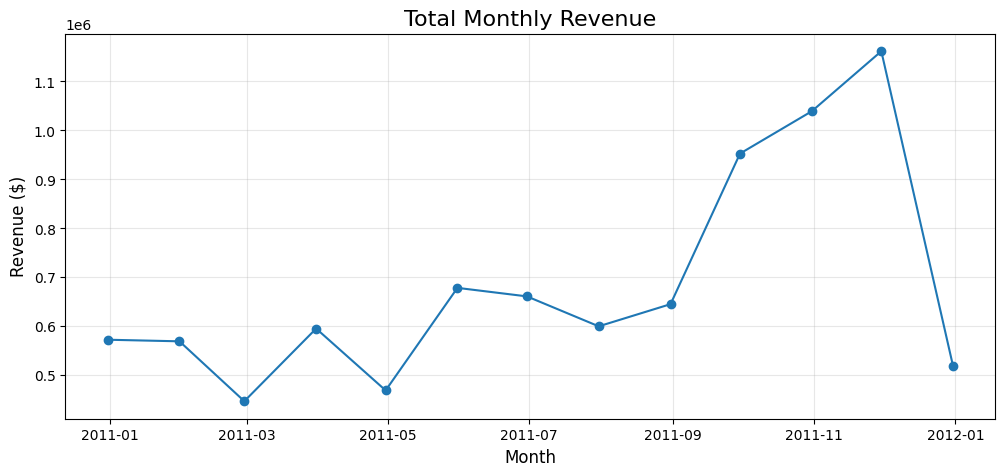

In [5]:
import matplotlib.pyplot as plt

# 1. Convert InvoiceDate to a real date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Group by Date and sum the Revenue
# We use 'resample' to group by Month ('M')
monthly_revenue = df.set_index('InvoiceDate')['Revenue'].resample('M').sum()

# 3. Plot the trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue, marker='o', linestyle='-', color='tab:blue')
plt.title('Total Monthly Revenue', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

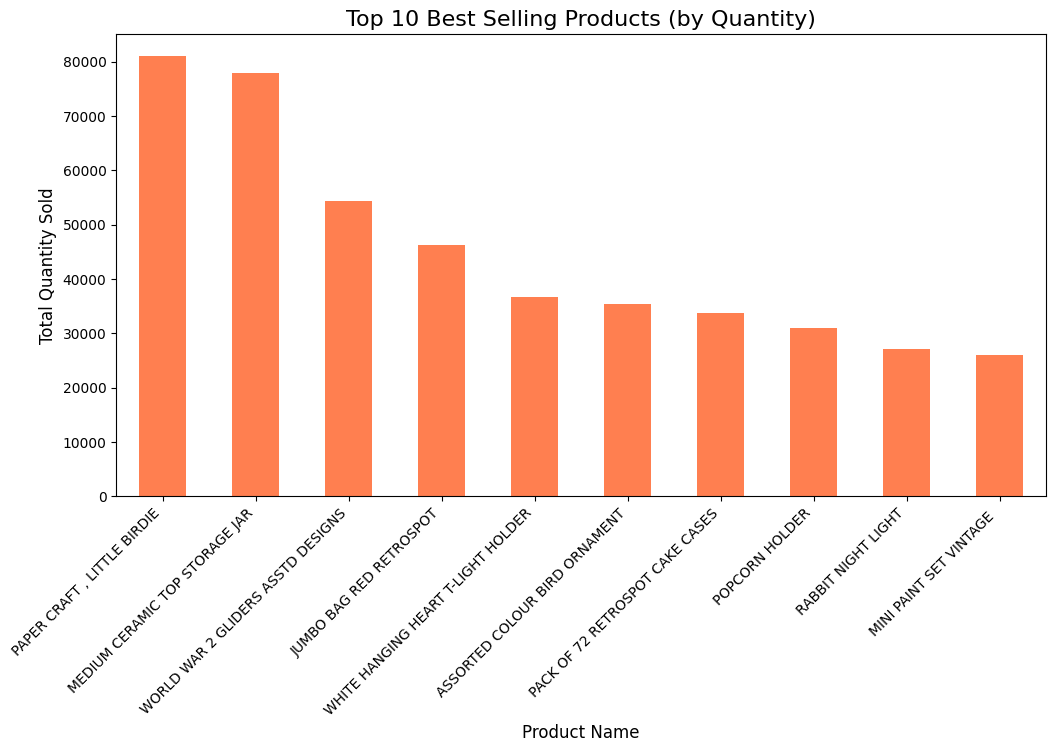

In [6]:
# 1. Get Top 10 products by total Quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# 2. Create the Bar Chart
plt.figure(figsize=(12, 6))
top_products.plot(kind='bar', color='coral')

# 3. Add labels and clean up the look
plt.title('Top 10 Best Selling Products (by Quantity)', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right') # Tilts the labels so they don't overlap
plt.show()

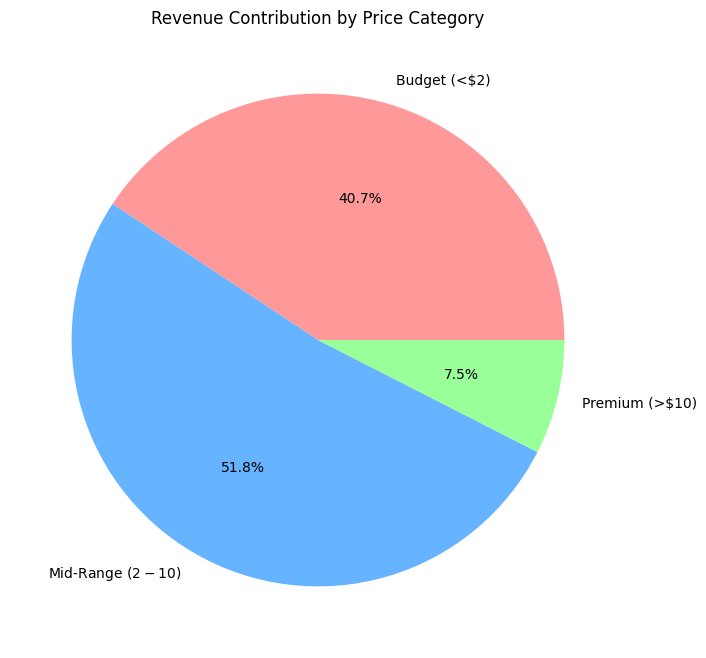

In [7]:
def price_tier(price):
    if price < 2: return 'Budget (<$2)'
    elif price < 10: return 'Mid-Range ($2-$10)'
    else: return 'Premium (>$10)'

df['PriceCategory'] = df['UnitPrice'].apply(price_tier)

category_revenue = df.groupby('PriceCategory')['Revenue'].sum()
plt.figure(figsize=(8, 8))
category_revenue.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Revenue Contribution by Price Category')
plt.ylabel('') 
plt.show()

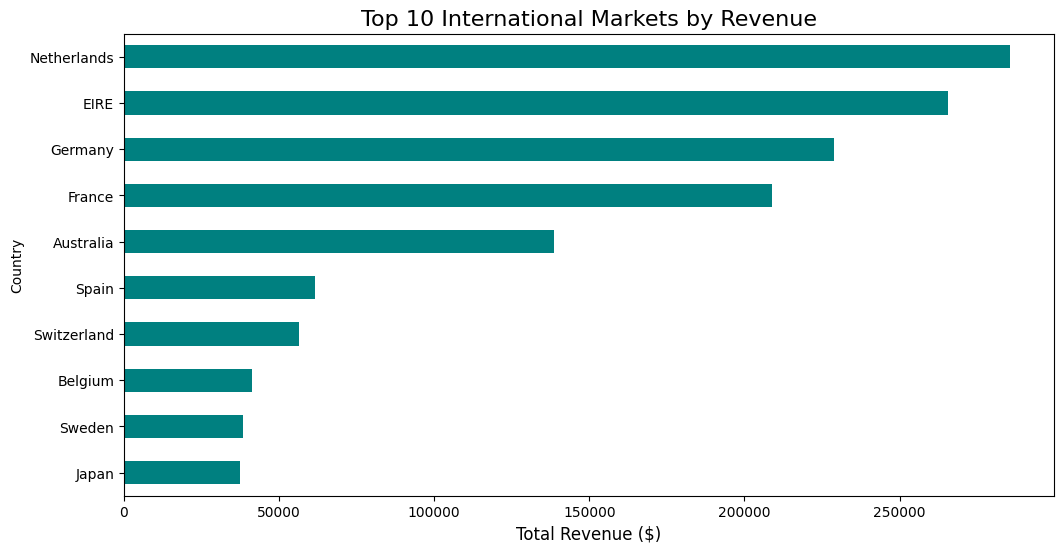

In [8]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

top_international = country_revenue.drop('United Kingdom').head(10)

plt.figure(figsize=(12, 6))
top_international.plot(kind='barh', color='teal') 
plt.title('Top 10 International Markets by Revenue', fontsize=16)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.gca().invert_yaxis() 
plt.show()

In [9]:
df.to_csv('cleaned_retail_data.csv', index=False)
print("File saved successfully!")

File saved successfully!
